In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import forestplot as fp

In [116]:
df_main = pd.DataFrame({
    "predictor": ["past_abx", "anemia", "renal_failure", "n_sites"],
    "term": ["past_abx", "anemia", "renal_failure", "n_sites"],
    "odds_ratio": [1.782782, 1.806273, 2.164435, 2.190094],
    "ci_lower": [1.376429, 1.316020, 1.117892, 1.755543],
    "ci_upper": [2.309100, 2.479158, 4.190725, 2.734206],
    "p_value": [1.183163e-05, 2.525018e-04, 2.198905e-02, 3.047208e-12]
})

df_cat = pd.DataFrame({
    "predictor": [
        "ethnicity_desc",
        "organism_bug",
        "prophylaxis_group",
        "organism_bug",
        "tfc_group",
        "prophylaxis_group",
        "site",
        "tfc_group",
        "prophylaxis_group",
        "prophylaxis_group",
        "tfc_group",
        "prophylaxis_group",
        "site",
        "prophylaxis_group",
        "tfc_group",
        "site"
    ],
    "category": [
        "asian",
        "proteus mirabilis",
        "co-amoxiclav (contains penicillin)",
        "klebsiella oxytoca",
        "gynaecological oncology",
        "clindamycin",
        "sputum",
        "uro_nephro",
        "gentamicin | teicoplanin",
        "no_prophylaxis",
        "obstetrics",
        "cefuroxime",
        "low_vaginal",
        "cefuroxime | gentamicin | metronidazole",
        "abdominal_gi",
        "urine"
    ],
    "odds_ratio": [
        2.893423, 0.208776, 0.435501, 0.133726, 2.508197, 0.382096,
        0.407931, 1.811119, 0.389305, 0.531461, 0.385358, 0.658191,
        0.301282, 2.250893, 1.471365, 1.475174
    ],
    "ci_lower": [
        2.209237, 0.124646, 0.322279, 0.061471, 1.653942, 0.237698,
        0.258800, 1.249318, 0.214093, 0.345436, 0.198482, 0.485359,
        0.119077, 1.043068, 1.019540, 1.010235
    ],
    "ci_upper": [
        3.789497, 0.349692, 0.588500, 0.290914, 3.803670, 0.614213,
        0.642995, 2.625554, 0.707910, 0.817664, 0.748182, 0.892568,
        0.762285, 4.857324, 2.124368, 2.154089
    ],
    "p_value": [
        1.178372e-14, 2.639790e-09, 6.256474e-08, 3.903750e-07,
        1.502684e-05, 7.110757e-05, 1.124072e-04, 1.719532e-03,
        1.986536e-03, 4.030423e-03, 4.847831e-03, 7.118485e-03,
        1.130569e-02, 3.869532e-02, 3.908309e-02, 4.414798e-02
    ]
})

In [117]:
uni_lr_results = pd.concat([df_main, df_cat], axis=0, ignore_index=True)
uni_lr_results.drop(columns='term', inplace=True)
uni_lr_results[['odds_ratio', 'ci_lower', 'ci_upper']] = uni_lr_results[['odds_ratio', 'ci_lower', 'ci_upper']].round(2)
uni_lr_results

,predictor,odds_ratio,ci_lower,ci_upper,p_value,category
0,past_abx,1.78,1.38,2.31,1.183163e-05,NaN
1,anemia,1.81,1.32,2.48,2.525018e-04,NaN
2,renal_failure,2.16,1.12,4.19,2.198905e-02,NaN
3,n_sites,2.19,1.76,2.73,3.047208e-12,NaN
4,ethnicity_desc,2.89,2.21,3.79,1.178372e-14,asian
5,organism_bug,0.21,0.12,0.35,2.639790e-09,proteus mirabilis
6,prophylaxis_group,0.44,0.32,0.59,6.256474e-08,co-amoxiclav (contains penicillin)
7,organism_bug,0.13,0.06,0.29,3.903750e-07,klebsiella oxytoca
8,tfc_group,2.51,1.65,3.80,1.502684e-05,gynaecological oncology
9,prophylaxis_group,0.38,0.24,0.61,7.110757e-05,clindamycin


In [118]:

predictor_name_mapping = {
    "past_abx": "Past antibiotic use",
    "anemia": "Anemia",
    "renal_failure": "Renal failure",
    "n_sites": "Number of sites",
    "ethnicity_desc": "Ethnicity",
    "organism_bug": "Organism",
    "prophylaxis_group": "Prophylaxis group",
    "tfc_group": "TFC group",
    "site": "Site"
}       

uni_lr_results['predictor'] = uni_lr_results['predictor'].map(predictor_name_mapping)


category_map = {
    "asian": "Asian",
    "proteus mirabilis": "P. mirabilis",
    "co-amoxiclav (contains penicillin)": "Co-amoxiclav",
    "klebsiella oxytoca": "K. oxytoca",
    "gynaecological oncology": "Gynae onc",
    "clindamycin": "Clindamycin",
    "sputum": "Sputum",
    "uro_nephro": "Uro/nephro",
    "gentamicin | teicoplanin": "Gent/teico",
    "no_prophylaxis": "No prophylaxis",
    "obstetrics": "Obstetrics",
    "cefuroxime": "Cefuroxime",
    "low_vaginal": "Low vaginal",
    "cefuroxime | gentamicin | metronidazole": "Cefurox/gent/metronidazole",
    "abdominal_gi": "Abdominal/GI",
    "urine": "Urine",
}

uni_lr_results['category'] = uni_lr_results['category'].map(category_map)

uni_lr_results['category'] = uni_lr_results['category'].fillna(uni_lr_results['predictor'])

In [119]:
# Format table for publication
# Combine OR and CI into single column
uni_lr_results['OR (95% CI)'] = uni_lr_results.apply(
    lambda row: f"{row['odds_ratio']:.2f} ({row['ci_lower']:.2f}–{row['ci_upper']:.2f})",
    axis=1
)

# Format p-values
def format_pvalue(p):
    if p < 0.001:
        return '<0.001'
    elif p < 0.01:
        return f'{p:.3f}'
    elif p < 0.05:
        return f'{p:.3f}'
    else:
        return f'{p:.3f}'

uni_lr_results['p-value'] = uni_lr_results['p_value'].apply(format_pvalue)

# Select and reorder columns for final table
table_for_export = uni_lr_results[['category', 'OR (95% CI)', 'p-value']].copy()
table_for_export.columns = ['Variable', 'OR (95% CI)', 'p-value']

# Reset index for clean numbering
table_for_export = table_for_export.reset_index(drop=True)
table_for_export

,Variable,OR (95% CI),p-value
0,Past antibiotic use,1.78 (1.38–2.31),<0.001
1,Anemia,1.81 (1.32–2.48),<0.001
2,Renal failure,2.16 (1.12–4.19),0.022
3,Number of sites,2.19 (1.76–2.73),<0.001
4,Asian,2.89 (2.21–3.79),<0.001
5,P. mirabilis,0.21 (0.12–0.35),<0.001
6,Co-amoxiclav,0.44 (0.32–0.59),<0.001
7,K. oxytoca,0.13 (0.06–0.29),<0.001
8,Gynae onc,2.51 (1.65–3.80),<0.001
9,Clindamycin,0.38 (0.24–0.61),<0.001


In [27]:
# Export to LaTeX
latex_table = table_for_export.to_latex(
    index=False, 
    escape=False,
    caption='Univariable logistic regression results',
    label='tab:univar_lr',
    position='htbp'
)
with open('univariable_lr_results.tex', 'w') as f:
    f.write(latex_table)

<Axes: xlabel='Odds ratio'>

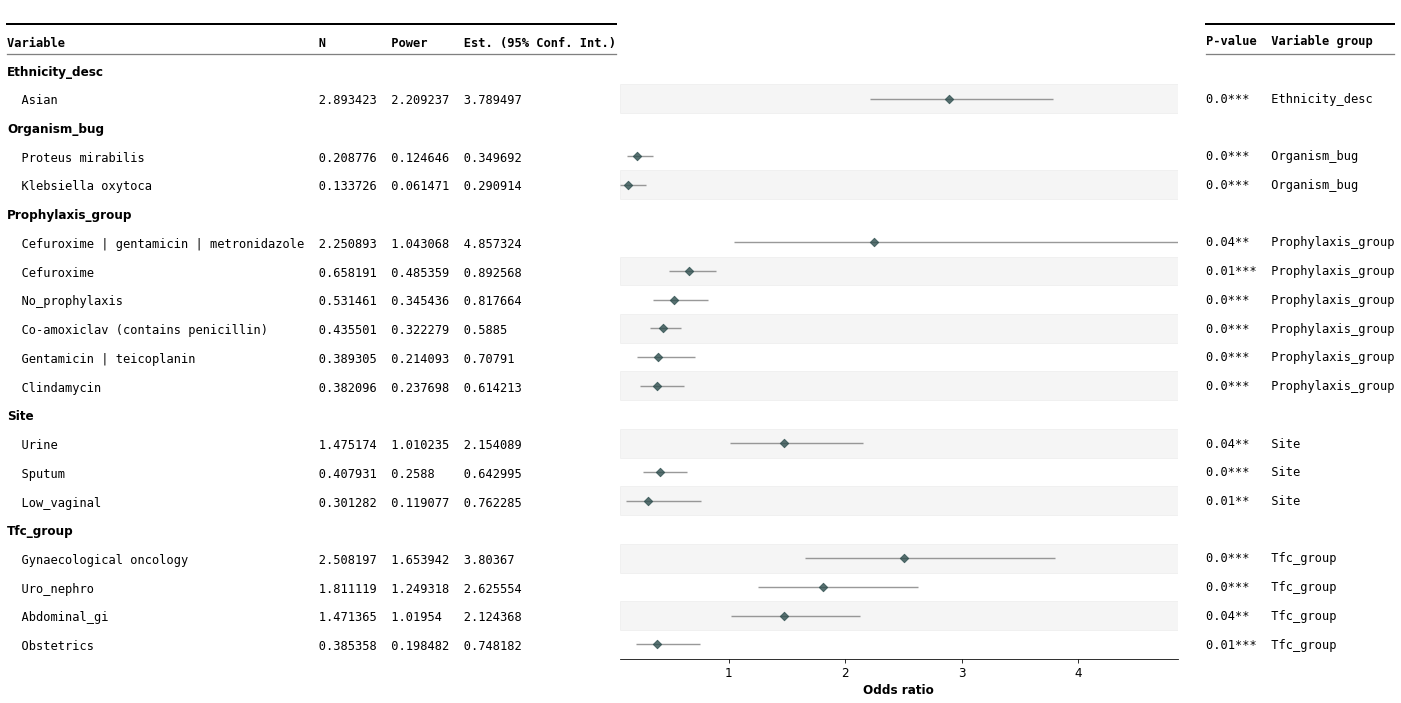

In [ ]:
# Use numeric p-values for plotting (forestplot internally uses np.isnan)
df_plot = df_cat.copy()
df_plot["formatted_pval"] = df_plot["p_value"].astype(str)
df_plot["p_value"] = (
    df_plot["formatted_pval"]
    .str.extract(r"([0-9]*\.?[0-9]+(?:e-?\d+)?)", expand=False)
    .astype(float)
)

fp.forestplot(df_plot,  # the dataframe with results data
              estimate="odds_ratio",  # col containing estimated effect size 
              ll="ci_lower", hl="ci_upper",  # lower & higher limits of conf. int.
              varlabel="category",  # column containing the varlabels to be printed on far left
              capitalize="capitalize",  # Capitalize labels
              pval="p_value",  # numeric p-values for internal computations
                annote=["odds_ratio", "ci_lower", "ci_upper"],  # columns to report on left of plot
               annoteheaders=["N", "Power", "Est. (95% Conf. Int.)"],  # ^corresponding headers
              rightannote=["formatted_pval", "category"],  # columns to report on right of plot 
              right_annoteheaders=["P-value", "Variable group"],  # ^corresponding headers
              groupvar="predictor",  # column containing group labels
            #   group_order=["labor factors", "occupation", "age", "health factors", 
            #                "family factors", "area of residence", "other factors"],                   
              xlabel="Odds ratio",  # x-label title
              sort=True,  # sort estimates in ascending order
              table=True,  # Format as a table
              color_alt_rows=True,
              figsize= (10, 12),  # adjust figure size
              
              # Additional kwargs for customizations
              **{"marker": "D",  # set maker symbol as diamond
                 "markersize": 35,  # adjust marker size
                 "xlinestyle": (0, (7, 5)),  # long dash for x-reference line 
                 "xlinecolor": "#808080",  # gray color for x-reference line
                 "xtick_size": 12,  # adjust x-ticker fontsize
                }  
              )

In [121]:

# -----------------------------
# 1. Copy results
# -----------------------------
plot_df = uni_lr_results.copy()

plot_df


,predictor,odds_ratio,ci_lower,ci_upper,p_value,category,OR (95% CI),p-value
0,Past antibiotic use,1.78,1.38,2.31,1.183163e-05,Past antibiotic use,1.78 (1.38–2.31),<0.001
1,Anemia,1.81,1.32,2.48,2.525018e-04,Anemia,1.81 (1.32–2.48),<0.001
2,Renal failure,2.16,1.12,4.19,2.198905e-02,Renal failure,2.16 (1.12–4.19),0.022
3,Number of sites,2.19,1.76,2.73,3.047208e-12,Number of sites,2.19 (1.76–2.73),<0.001
4,Ethnicity,2.89,2.21,3.79,1.178372e-14,Asian,2.89 (2.21–3.79),<0.001
5,Organism,0.21,0.12,0.35,2.639790e-09,P. mirabilis,0.21 (0.12–0.35),<0.001
6,Prophylaxis group,0.44,0.32,0.59,6.256474e-08,Co-amoxiclav,0.44 (0.32–0.59),<0.001
7,Organism,0.13,0.06,0.29,3.903750e-07,K. oxytoca,0.13 (0.06–0.29),<0.001
8,TFC group,2.51,1.65,3.80,1.502684e-05,Gynae onc,2.51 (1.65–3.80),<0.001
9,Prophylaxis group,0.38,0.24,0.61,7.110757e-05,Clindamycin,0.38 (0.24–0.61),<0.001


AttributeError: module 'matplotlib.ticker' has no attribute 'Scalarformatter'

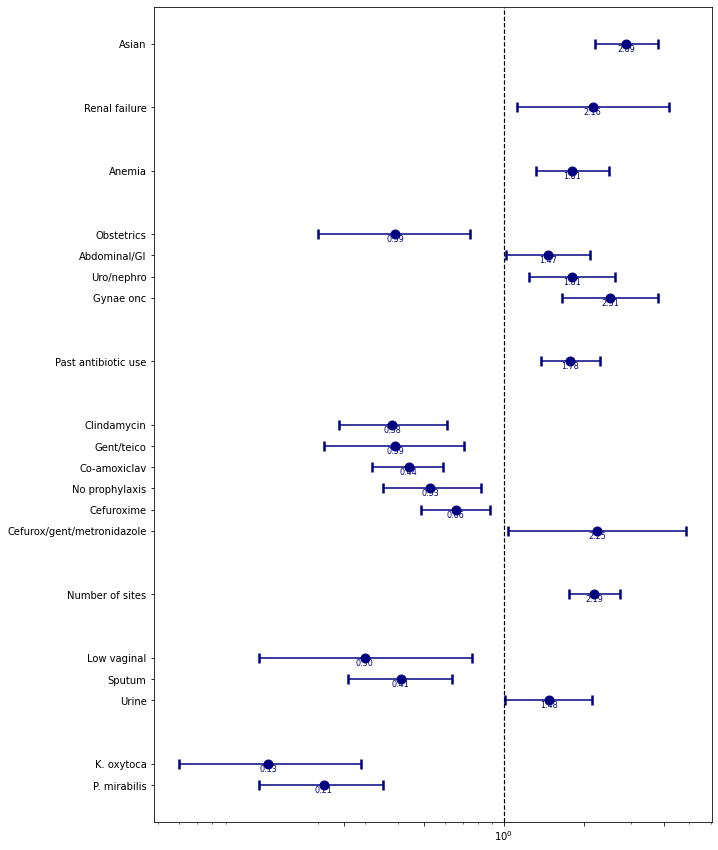

In [138]:
plot_df = uni_lr_results.copy()

# -----------------------------
# Sort groups internally by OR
# -----------------------------
group_order = ["Organism", "Site", 'Number of sites', "Prophylaxis group", 'Past antibiotic use', "TFC group", 'Anemia', 'Renal failure', 'Ethnicity']

plot_df["group"] = pd.Categorical(
    plot_df["predictor"],
    categories=group_order,
    ordered=True
)

plot_df = plot_df.sort_values(
    ["group", "odds_ratio"],
    ascending=[True, False]
).reset_index(drop=True)


# -----------------------------
# Create y positions with gaps between groups
# -----------------------------
y_positions = []
current_y = 0

for grp in group_order:
    current_grp = plot_df[plot_df["group"] == grp]
    for _ in range(len(current_grp)):
        y_positions.append(current_y)
        current_y += 0.5
    if len(current_grp) > 0:
        current_y += 1  # blank line only if group exists

plot_df["y"] = y_positions

# -----------------------------
# Dynamic x-axis limits for log scale
# -----------------------------
xmin = plot_df["ci_lower"].min()
xmax = plot_df["ci_upper"].max()

# widen slightly for visual padding on log scale
xmin = np.floor(xmin)
xmax = np.ceil(xmax)


# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 15))

ax.errorbar(
    plot_df["odds_ratio"],
    plot_df["y"],
    xerr=[
        plot_df["odds_ratio"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["odds_ratio"]
    ],
    fmt="o",
    color="navy",
    ecolor="navy",
    elinewidth=1.5,
    capsize=5,
    capthick=2.5,
    markersize=9,
)

# Annotate OR values
for _, row in plot_df.iterrows():
    ax.text(
        row["odds_ratio"],
        row["y"] - 0.22,
        f"{row['odds_ratio']:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="navy"
    )

# Reference line at OR = 1
ax.axvline(1, color="black", linestyle="--", linewidth=1.2)

# Axes
ax.set_yticks(plot_df["y"])
ax.set_yticklabels(plot_df["category"], fontsize=10)

ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4])
ax.get_xaxis().set_major_formatter(mticker.Scalarformatter())


# Use log ticks automatically
ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Odds ratio (95% CI, log scale)", fontsize=12)
ax.set_title(
    "Factors associated with ESBL infection (univariable analysis)",
    fontsize=16,
    weight="bold",
    pad=12
)

# Style
ax.grid(axis="x", linestyle=":", alpha=0.95)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [177]:
df_cat = pd.DataFrame([
    ["organism_bug", "klebsiella oxytoca", 0.133726, 0.061471, 0.290914, 3.903750e-07],
    ["organism_bug", "klebsiella pneumoniae", 1.176387, 0.954388, 1.450024, 1.278986e-01],
    ["organism_bug", "proteus mirabilis", 0.208776, 0.124646, 0.349692, 2.639790e-09],

    ["site", "drain", 0.973373, 0.622961, 1.520889, 9.056515e-01],
    ["site", "high_vaginal", 0.522222, 0.258295, 1.055832, 7.049637e-02],
    ["site", "low_vaginal", 0.301282, 0.119077, 0.762285, 1.130669e-02],
    ["site", "sputum", 0.407931, 0.258800, 0.642995, 1.124072e-04],
    ["site", "tips_devices", 1.265385, 0.769022, 2.082123, 3.542690e-01],
    ["site", "tissue/biopsy", 0.783333, 0.442369, 1.387102, 4.022542e-01],
    ["site", "urine", 1.475174, 1.010235, 2.154089, 4.414798e-02],
    ["site", "wound", 0.913212, 0.624517, 1.335363, 6.395901e-01],

    ["tfc_group", "abdominal_gi", 1.471865, 1.019540, 2.124968, 3.908809e-02],
    ["tfc_group", "cardiothoracic", 0.682670, 0.442786, 1.052512, 8.394166e-02],
    ["tfc_group", "gynaecological oncology", 2.508197, 1.653942, 3.803670, 1.502684e-05],
    ["tfc_group", "gynaecology", 0.860025, 0.513856, 1.439398, 5.660608e-01],
    ["tfc_group", "neuro_ent", 0.667881, 0.430620, 1.035866, 7.145138e-02],
    ["tfc_group", "obstetrics", 0.383538, 0.198482, 0.741812, 4.647831e-03],
    ["tfc_group", "ortho_plastics", 0.699117, 0.440629, 1.109245, 1.285729e-01],
    ["tfc_group", "uro_nephro", 1.811119, 1.249318, 2.625554, 1.719532e-03],
    ["tfc_group", "vascular", 1.104048, 0.699632, 1.742234, 6.706357e-01],

    ["prophylaxis_group", "cefuroxime", 0.658191, 0.485359, 0.892568, 7.118485e-03],
    ["prophylaxis_group", "cefuroxime | gentamicin", 0.657870, 0.314386, 1.376629, 2.663440e-01],
    ["prophylaxis_group", "cefuroxime | gentamicin | metronidazole", 2.250893, 1.043068, 4.857324, 3.869532e-02],
    ["prophylaxis_group", "clindamycin", 0.382096, 0.237698, 0.614213, 7.110757e-05],
    ["prophylaxis_group", "co-amoxiclav (contains penicillin)", 0.435501, 0.322279, 0.588500, 6.256474e-08],
    ["prophylaxis_group", "gentamicin", 0.637448, 0.360510, 1.127125, 1.215165e-01],
    ["prophylaxis_group", "gentamicin | metronidazole", 1.008734, 0.454877, 2.236964, 9.829268e-01],
    ["prophylaxis_group", "gentamicin | teicoplanin", 0.389305, 0.214093, 0.707910, 1.986536e-03],
    ["prophylaxis_group", "metronidazole", 0.896139, 0.588761, 1.364144, 6.091297e-01],
    ["prophylaxis_group", "no_prophylaxis", 0.531461, 0.345436, 0.817664, 4.030423e-03],
    ["prophylaxis_group", "vancomycin", 0.762803, 0.534224, 1.089183, 1.362557e-01],

    ["ethnicity_desc", "asian", 2.893423, 2.209237, 3.789497, 1.178872e-14],
    ["ethnicity_desc", "black", 1.258335, 0.889209, 1.780692, 1.945880e-01],
], columns=[
    "predictor", "category", "odds_ratio", "ci_lower", "ci_upper", "p_value"
])

df_cat.head()

,predictor,category,odds_ratio,ci_lower,ci_upper,p_value
0,organism_bug,klebsiella oxytoca,0.133726,0.061471,0.290914,3.903750e-07
1,organism_bug,klebsiella pneumoniae,1.176387,0.954388,1.450024,1.278986e-01
2,organism_bug,proteus mirabilis,0.208776,0.124646,0.349692,2.639790e-09
3,site,drain,0.973373,0.622961,1.520889,9.056515e-01
4,site,high_vaginal,0.522222,0.258295,1.055832,7.049637e-02


In [178]:
df_cat['predictor'].unique()

<StringArray>
['organism_bug', 'site', 'tfc_group', 'prophylaxis_group', 'ethnicity_desc']
Length: 5, dtype: str

In [179]:

predictor_name_mapping = {
    "ethnicity_desc": "Ethnicity",
    "organism_bug": "Organism",
    "prophylaxis_group": "Prophylaxis group",
    "tfc_group": "TFC group",
    "site": "Site",
}  

if set(df_cat['predictor']) - set(predictor_name_mapping.keys()) == set():
    df_cat['predictor'] = df_cat['predictor'].map(predictor_name_mapping)
else:
    print(set(df_cat['predictor']) - set(predictor_name_mapping.keys()))

if set(df_cat['category']) - set(category_map.keys()) == set():
    df_cat['category'] = df_cat['category'].map(category_map)
else:
    print(set(df_cat['category']) - set(category_map.keys()))

# Map category values to more concise labels
category_map = {
    "asian": "Asian",
    "white": "White",
    "black": "Black",

    "klebsiella pneumoniae": "K. pneumoniae",
    "proteus mirabilis": "P. mirabilis",
    "klebsiella oxytoca": "K. oxytoca",


    "co-amoxiclav (contains penicillin)": "Co-amoxiclav",
    "gentamicin": "Gentamicin",
    "gentamicin | metronidazole": "Gent/metronidazole",
    "metronidazole": "Metronidazole",
    "vancomycin": "Vancomycin",
    "clindamycin": "Clindamycin",
    "gentamicin | teicoplanin": "Gent/teico",
    "cefuroxime | gentamicin | metronidazole": "Cefurox/gent/metronidazole",
    "no_prophylaxis": "No prophylaxis",
    "cefuroxime": "Cefuroxime",
    "cefuroxime | gentamicin": "Cefurox/gent",

    "drain": "Drain",
    "high_vaginal": "High vaginal",
    "tips_devices": "Tips/devices",
    "tissue/biopsy": "Tissue/biopsy",
    "wound": "Wound",
    "urine": "Urine",
    "sputum": "Sputum",
    "low_vaginal": "Low vaginal",


    "gynaecological oncology": "Gynae onc",
    "uro_nephro": "Uro/nephro",
    "obstetrics": "Obstetrics",
    "abdominal_gi": "Abdominal/GI",
    "gynaecology": "Gynaecology",
    "cardiothoracic": "Cardiothoracic",
    "neuro_ent": "Neuro/ENT",
    "ortho_plastics": "Ortho/plastics",
    "vascular": "Vascular"
    
}

if set(df_cat['category']) - set(category_map.keys()) == set():
    df_cat['category'] = df_cat['category'].map(category_map)
else:
    print(set(df_cat['category']) - set(category_map.keys()))

{'Cefurox/gent', 'Wound', 'Cardiothoracic', 'Vancomycin', 'Gynae onc', 'Obstetrics', 'Asian', 'Abdominal/GI', 'Uro/nephro', 'Cefurox/gent/metronidazole', 'Drain', 'Cefuroxime', 'Gent/metronidazole', 'Tips/devices', 'Tissue/biopsy', 'K. oxytoca', 'Ortho/plastics', 'Vascular', 'High vaginal', 'Gent/teico', 'Black', 'Neuro/ENT', 'Metronidazole', 'Sputum', 'K. pneumoniae', 'Gentamicin', 'No prophylaxis', 'Low vaginal', 'Clindamycin', 'Urine', 'Co-amoxiclav', 'P. mirabilis', 'Gynaecology'}


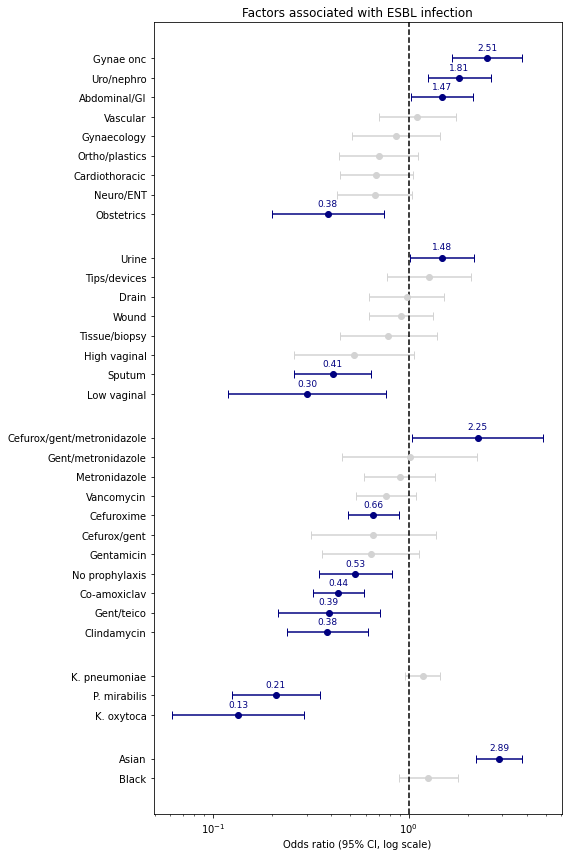

In [194]:
plot_df = df_cat.copy()

# Choose the label column
label_col = "category"   # change to "term" if needed

# Significant if p < 0.05
plot_df["significant"] = plot_df["p_value"] < 0.05

# Sort for nicer display
plot_df = plot_df.sort_values(['predictor',"odds_ratio"], ascending=[True, True]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 12), constrained_layout=True)

# -----------------------------
# Create y positions with gaps between groups
# -----------------------------
y_positions = []
current_y = 0

for grp in plot_df["predictor"].unique():
    current_grp = plot_df[plot_df["predictor"] == grp]
    for _ in range(len(current_grp)):
        y_positions.append(current_y)
        current_y += 0.8
    if len(current_grp) > 0:
        current_y += 1  # blank line only if group exists

plot_df["y"] = y_positions

for i, row in plot_df.iterrows():
    lower_err = row["odds_ratio"] - row["ci_lower"]
    upper_err = row["ci_upper"] - row["odds_ratio"]
    
    color = "navy" if row["significant"] else "lightgray"
    
    ax.errorbar(
        x=row["odds_ratio"],
        y=row["y"] ,
        xerr=[[lower_err], [upper_err]],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=4
    )

    # Optional text label for OR value
    if row["significant"]:
        ax.text(
            row["odds_ratio"],
            row["y"] + 0.25,
            f"{row['odds_ratio']:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=color
        )

ax.axvline(1, color="black", linestyle="--", linewidth=1.5)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df[label_col])
ax.set_xscale("log")
ax.set_xlabel("Odds ratio (95% CI, log scale)")
ax.set_title("Factors associated with ESBL infection")


plt.tight_layout()
fig.savefig("forest_plot.png", dpi=300, bbox_inches="tight", pad_inches=0.2)

plt.show()

